In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Convert to DataFrame
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['species'] = iris.target
data['species'] = data['species'].map({0:'setosa',1:'versicolor',2:'virginica'})

# Convert dataset to list of lists
data_list = data.values.tolist()
print("Dataset as list of lists:")
print(data_list[:5])

# Mean and Standard Deviation for each column
print("\nMean of each column:")
print(data.iloc[:,:4].mean())

print("\nStandard Deviation of each column:")
print(data.iloc[:,:4].std())

# Mean & Std for each species
print("\nGrouped Mean:")
print(data.groupby('species').mean())

print("\nGrouped Standard Deviation:")
print(data.groupby('species').std())

Dataset as list of lists:
[[5.1, 3.5, 1.4, 0.2, 'setosa'], [4.9, 3.0, 1.4, 0.2, 'setosa'], [4.7, 3.2, 1.3, 0.2, 'setosa'], [4.6, 3.1, 1.5, 0.2, 'setosa'], [5.0, 3.6, 1.4, 0.2, 'setosa']]

Mean of each column:
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

Standard Deviation of each column:
sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64

Grouped Mean:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                  5.006             3.428              1.462   
versicolor              5.936             2.770              4.260   
virginica               6.588             2.974              5.552   

            petal width (cm)  
species                       
setosa                 0.246  
versicolor             1.3

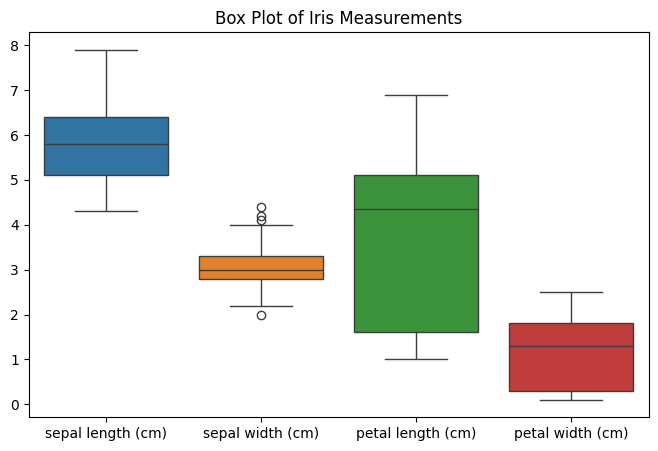

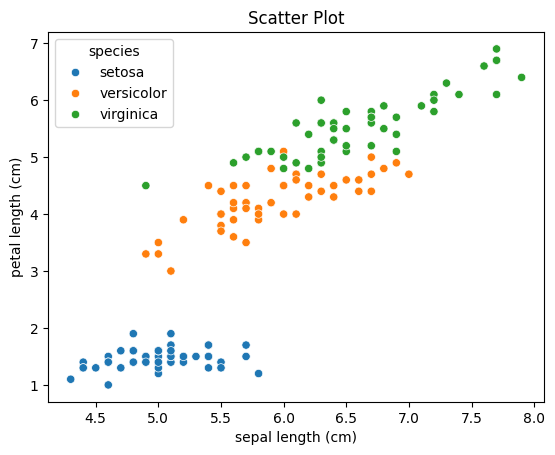

In [11]:
# Box plot
plt.figure(figsize=(8,5))
sns.boxplot(data=data.iloc[:,:4])
plt.title("Box Plot of Iris Measurements")
plt.show()

# Scatter plot
sns.scatterplot(x='sepal length (cm)', y='petal length (cm)', hue='species', data=data)
plt.title("Scatter Plot")
plt.show()

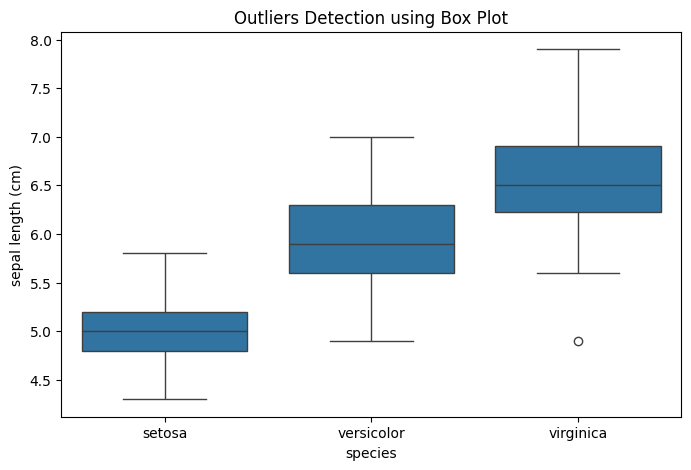

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='species', y='sepal length (cm)', data=data)
plt.title("Outliers Detection using Box Plot")
plt.show()

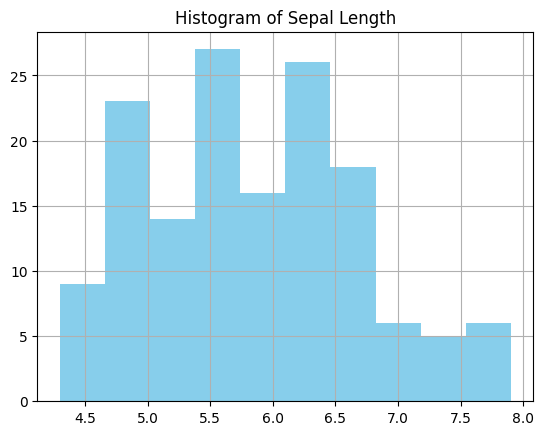

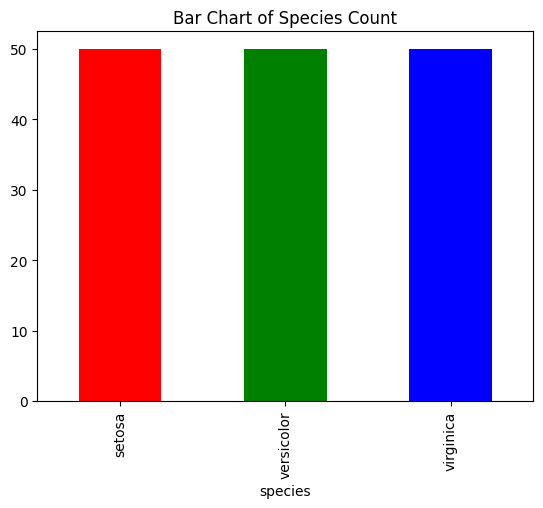

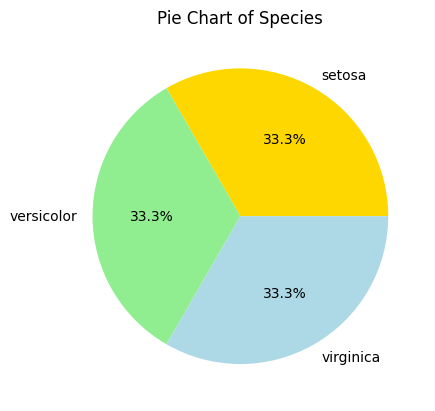

In [13]:
# Histogram
data['sepal length (cm)'].hist(color='skyblue')
plt.title("Histogram of Sepal Length")
plt.show()

# Bar Chart (species count)
species_count = data['species'].value_counts()
species_count.plot(kind='bar', color=['red','green','blue'])
plt.title("Bar Chart of Species Count")
plt.show()

# Pie Chart
species_count.plot(kind='pie', autopct='%1.1f%%', colors=['gold','lightgreen','lightblue'])
plt.title("Pie Chart of Species")
plt.ylabel('')
plt.show()

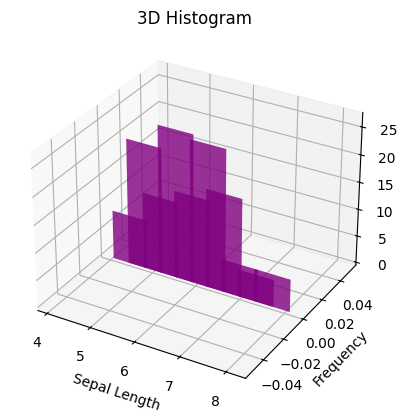

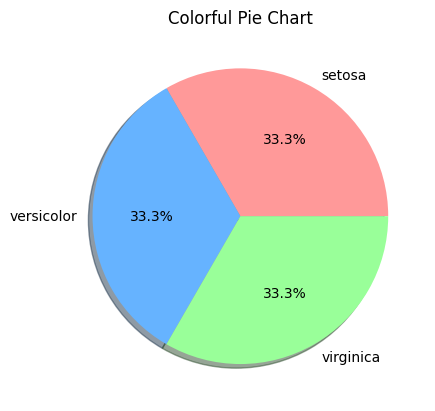

In [14]:
from mpl_toolkits.mplot3d import Axes3D

# 3D Histogram
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

hist, xedges = np.histogram(data['sepal length (cm)'], bins=10)

xs = (xedges[:-1] + xedges[1:])/2
ys = hist

ax.bar(xs, ys, zs=0, zdir='y', color='purple', alpha=0.8)
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Frequency')
ax.set_title('3D Histogram')
plt.show()

# Colorful Pie Chart
plt.pie(species_count, labels=species_count.index,
        autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff','#99ff99'],
        shadow=True)
plt.title("Colorful Pie Chart")
plt.show()

Intercept: -0.3630755213190291
Slope: [0.41575542]


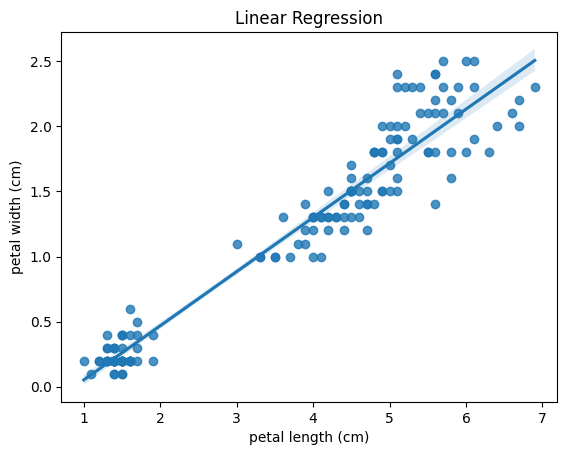

In [15]:
from sklearn.linear_model import LinearRegression

X = data[['petal length (cm)']]
y = data['petal width (cm)']

model = LinearRegression()
model.fit(X,y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_)

# Regression Plot
sns.regplot(x='petal length (cm)', y='petal width (cm)', data=data)
plt.title("Linear Regression")
plt.show()

In [16]:
corr_matrix = data.iloc[:,:4].corr()
print(corr_matrix)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


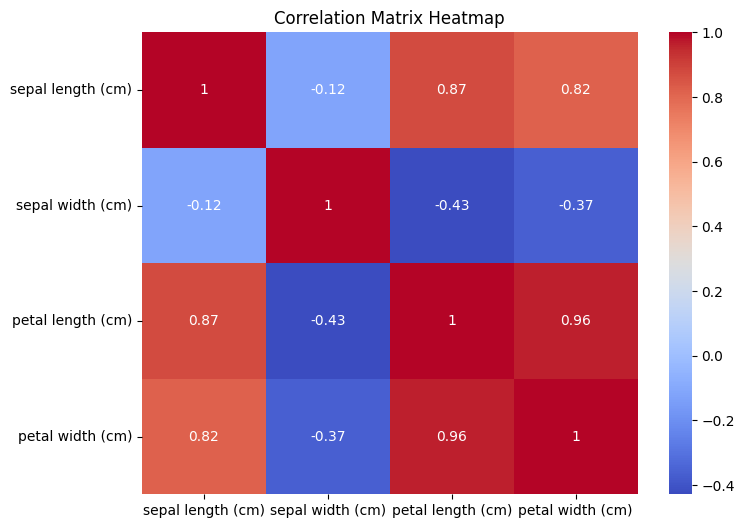

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

In [18]:
from scipy.stats import f_oneway

setosa = data[data['species']=='setosa']['sepal length (cm)']
versicolor = data[data['species']=='versicolor']['sepal length (cm)']
virginica = data[data['species']=='virginica']['sepal length (cm)']

anova_result = f_oneway(setosa, versicolor, virginica)

print("ANOVA Result:")
print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

ANOVA Result:
F-statistic: 119.26450218450468
p-value: 1.6696691907693826e-31
